# Replication: Adams & MacKay (2007) Figure 3

Dow Jones Industrial Average daily returns, July 3 1972 - June 30 1975.

Paper parameters:
- Returns: $R_t = p_t^{close} / p_{t-1}^{close} - 1$
- Univariate Gaussian with unknown mean and variance
- Gamma prior on precision: $a = 1$, $b = 10^{-4}$
  (NIG: $\alpha_0 = 1$, $\beta_0 = 10^{-4}$)
- Prior mean: $\mu_0 = 0$, $\kappa_0 = 1$
- Constant hazard $\lambda = 250$

Data source: [fja05680/dow-sp500-100-years](https://github.com/fja05680/dow-sp500-100-years)
(DJI daily close, 1885-present). The 1972-75 subset is bundled as
`dji_1972_1975.csv` for reproducibility since Yahoo Finance does not
serve data this far back.

Reference: Adams, R. P., & MacKay, D. J. C. (2007).
Bayesian Online Changepoint Detection. arXiv:0710.3742.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

from bocpd import BOCPD, ConstantHazard, UnivariateNormalNIG

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _here = Path.cwd()

## Load Dow Jones data (1972-1975)

In [2]:
df = pd.read_csv(_here / "dji_1972_1975.csv", index_col="Date", parse_dates=True)
close = df["Close"].values
dates = df.index

# Simple returns as in the paper: R_t = p_t / p_{t-1} - 1
returns = np.diff(close) / close[:-1]
dates_returns = dates[1:]

print(f"Observations: {len(returns)} trading days")
start = dates_returns[0].strftime("%Y-%m-%d")
end = dates_returns[-1].strftime("%Y-%m-%d")
print(f"Date range: {start} to {end}")

Observations: 753 trading days
Date range: 1972-07-05 to 1975-06-30


## Run BOCPD with paper parameters

In [3]:
detector = BOCPD(
    model_factory=lambda: UnivariateNormalNIG(
        mu0=0.0,
        kappa0=1.0,
        alpha0=1.0,
        beta0=1e-4,
    ),
    hazard_fn=ConstantHazard(lam=250),
)
result = detector.run(returns)

## Replicate Figure 3

Top panel: daily returns with predictive standard deviation overlay.
Bottom panel: run-length posterior (grayscale, log scale).
Three events marked as in the paper:
- Jan 30, 1973: conviction of G. Gordon Liddy and James W. McCord Jr.
- Oct 19, 1973: OPEC embargo begins
- Aug 9, 1974: resignation of President Nixon

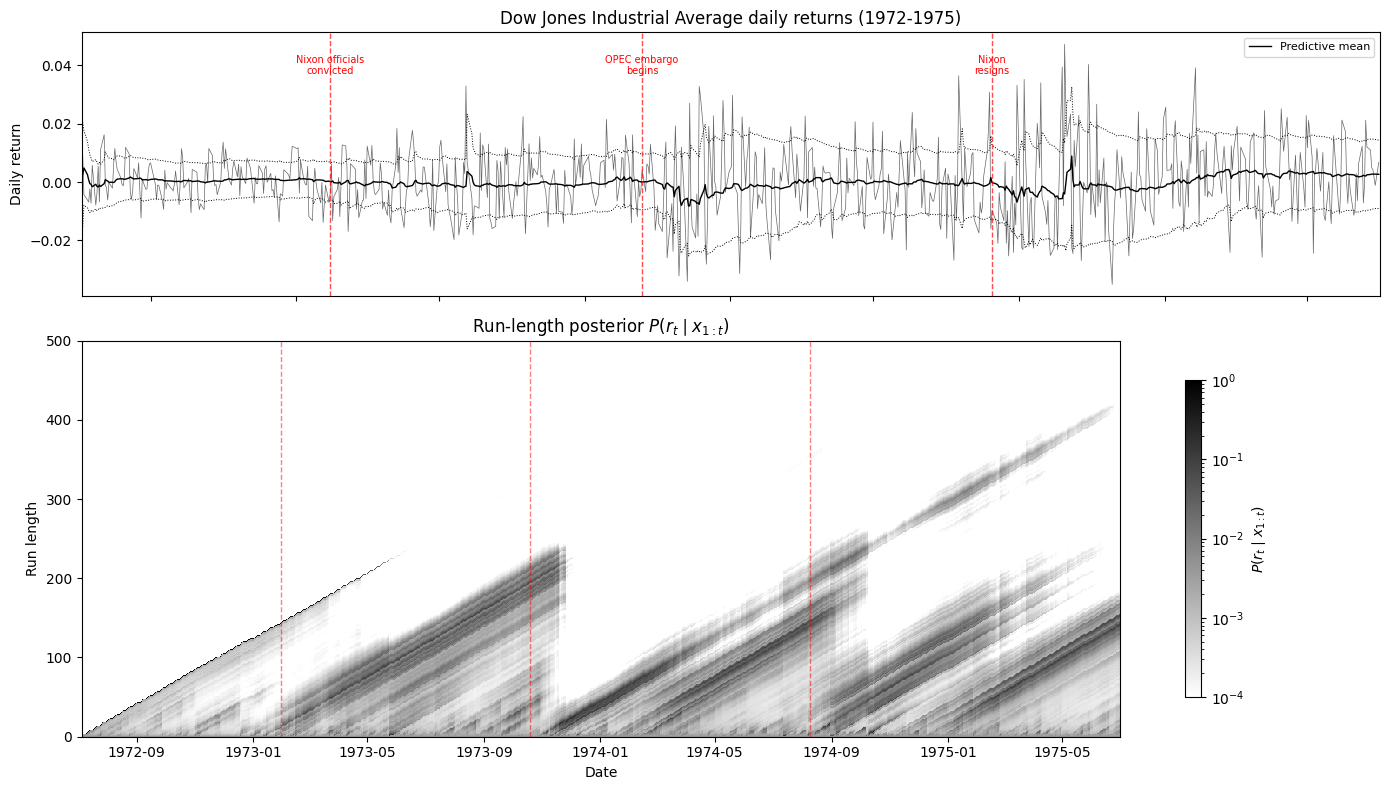

In [4]:
posteriors = result["run_length_posterior"]
erl = result["expected_run_length"]
T = len(posteriors)
max_rl = max(len(p) for p in posteriors)
rl_matrix = np.zeros((max_rl, T))
for t, p in enumerate(posteriors):
    rl_matrix[: len(p), t] = p

rl_matrix_clipped = np.clip(rl_matrix, 1e-4, 1.0)

# Historical events marked in the paper
events = {
    "1973-01-30": "Nixon officials\nconvicted",
    "1973-10-19": "OPEC embargo\nbegins",
    "1974-08-09": "Nixon\nresigns",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, height_ratios=[1, 1.5])

# -- Top panel: daily returns with predictive +/-1 std --
ax_top = axes[0]
ax_top.plot(dates_returns, returns, color="0.4", linewidth=0.5)

pred_mean = result["predictive_mean"]
pred_std = np.sqrt(result["predictive_var"])
ax_top.plot(
    dates_returns, pred_mean, color="black", linewidth=1, label="Predictive mean"
)
ax_top.plot(
    dates_returns, pred_mean + pred_std, color="black", linewidth=0.7, linestyle=":"
)
ax_top.plot(
    dates_returns, pred_mean - pred_std, color="black", linewidth=0.7, linestyle=":"
)
ax_top.legend(fontsize=8)
ax_top.set_ylabel("Daily return")
ax_top.set_title("Dow Jones Industrial Average daily returns (1972-1975)")

for date_str, label in events.items():
    event_date = pd.Timestamp(date_str)
    ax_top.axvline(event_date, color="red", alpha=0.7, linewidth=1, linestyle="--")
    ymin, ymax = ax_top.get_ylim()
    ax_top.text(
        event_date,
        ymax * 0.85,
        label,
        fontsize=7,
        ha="center",
        va="top",
        color="red",
    )

# -- Bottom panel: run-length posterior --
ax_bot = axes[1]

# Use date-based x-axis via pcolormesh for proper alignment with top panel
run_lengths = np.arange(max_rl + 1)
# Create date edges: one extra date needed for pcolormesh
date_edges = np.append(dates_returns, dates_returns[-1] + pd.Timedelta(days=1))

im = ax_bot.pcolormesh(
    date_edges,
    run_lengths,
    rl_matrix_clipped,
    cmap="gray_r",
    norm=LogNorm(vmin=1e-4, vmax=1.0),
    shading="flat",
    rasterized=True,
)
ax_bot.set_ylim(0, 500)

for date_str in events:
    event_date = pd.Timestamp(date_str)
    ax_bot.axvline(event_date, color="red", alpha=0.5, linewidth=1, linestyle="--")

fig.colorbar(im, ax=ax_bot, label=r"$P(r_t \mid x_{1:t})$", shrink=0.8)
ax_bot.set_xlabel("Date")
ax_bot.set_ylabel("Run length")
ax_bot.set_title(r"Run-length posterior $P(r_t \mid x_{1:t})$")

fig.tight_layout()
plt.show()